# 0. The Blast Radius blind spot

Atlassian prioritises tickets by technical severity. That leaves a second question unanswered: **how many collaborators may be affected when one customer is blocked?**

**Business question:** Does current ticket priority recognise collaboration reach, especially when highly collaborative customers are concentrated on non-Free plans?

The notebook follows one evidence chain:

1. verify that the supplied fields and joins are reliable;
2. inspect the raw collaboration pattern before selecting tiers;
3. test whether collaboration relates to commercial-plan concentration;
4. test whether existing priority already recognises that collaboration;
5. simulate a limited queue change;
6. identify the data Atlassian would need to validate the change.

Observed findings, business interpretations and future hypotheses are labelled separately. The data can establish relationships and workload; it cannot prove revenue impact, SLA improvement or causation.

### How the notebook starts

**Why:** every later table and chart must use the same files, definitions and visual conventions.

**How:** the next cell imports pandas for tables, Matplotlib for charts and scikit-learn for validation. It reads each CSV twice conceptually: the `_raw` frames preserve the supplied values, while separate working frames receive safe formatting changes. The helper functions only standardise a source table and save a figure.

**How to read the output:** the printed row counts confirm that all three inputs loaded. No analytical conclusion is drawn at this stage.

In [1]:
from pathlib import Path
import os
import tempfile
import warnings

ROOT = Path.cwd()
DATA = ROOT / "Given Data"
FIGURES = ROOT / "outputs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "atlassian-datathon-mpl"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 30)
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE, TEAL, AMBER, PURPLE, RED, GREY, LIGHT_GREY = (
    "#1868DB", "#008DA6", "#FFAB00", "#6554C0", "#DE350B", "#6B778C", "#DFE1E6"
)
TIER_ORDER = ["Standard", "Elevated", "Hub"]
TIER_COLORS = {"Standard": GREY, "Elevated": AMBER, "Hub": PURPLE}

def clean_source(raw):
    frame = raw.copy(deep=True)
    frame.columns = frame.columns.str.strip().str.lower().str.replace(r"\s+", "_", regex=True)
    for column in frame.select_dtypes(include="object"):
        frame[column] = frame[column].str.strip().replace("", pd.NA)
    return frame

def save_show(fig, filename):
    fig.savefig(FIGURES / filename, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()

customers_raw = pd.read_csv(DATA / "customers.csv")
tickets_raw = pd.read_csv(DATA / "customer_support_tickets.csv")
usage_raw = pd.read_csv(DATA / "product_usage.csv")

customers = clean_source(customers_raw)
tickets = clean_source(tickets_raw)
usage = clean_source(usage_raw)
customers["customer_email"] = customers["customer_email"].str.lower()
tickets["customer_email"] = tickets["customer_email"].str.lower()
usage["collaborators"] = pd.to_numeric(usage["collaborators"], errors="coerce")

print(f"Loaded {len(customers):,} customers, {len(tickets):,} tickets and {len(usage):,} usage rows.")

Loaded 8,320 customers, 8,469 tickets and 42,210 usage rows.


## 1. What can the data safely tell us?

Before looking for a story, we preserve the raw tables and create separate cleaned working copies.

- customers: one row per customer ID;
- product usage: one row per customer-product-month;
- support tickets: one row per ticket.

### Why clean and audit first?

Incorrect keys or joins can manufacture a convincing but false relationship. A raw ticket-to-usage join would repeat each ticket for every monthly usage row, so usage must be aggregated before it reaches ticket grain.

### What the next cell does

1. Parses dates into new columns instead of overwriting the supplied text.
2. Checks missing values and duplicate keys in the fields used by this analysis.
3. validates that every usage customer and ticket email can reach the customer master.
4. Flags impossible timestamp order, invalid active days and identity conflicts.
5. Reconciles raw and cleaned row counts.

**Decision rule:** drop or impute a row only if a problem affects the variables required for collaboration, plan or priority analysis. Otherwise preserve the row and flag the limitation.

In [2]:
customers["account_created_date_parsed"] = pd.to_datetime(
    customers["account_created_date"], errors="coerce"
)
usage["month_parsed"] = pd.to_datetime(
    usage["month"], format="%Y-%m", errors="coerce"
)
tickets["first_response_time_parsed"] = pd.to_datetime(
    tickets["first_response_time"], dayfirst=True, errors="coerce"
)
tickets["time_to_resolution_parsed"] = pd.to_datetime(
    tickets["time_to_resolution"], dayfirst=True, errors="coerce"
)

required_missing = (
    customers[["customer_id", "customer_email", "plan_type"]].isna().sum().sum()
    + usage[["customer_id", "month", "collaborators"]].isna().sum().sum()
    + tickets[["ticket_id", "customer_email", "ticket_priority"]].isna().sum().sum()
)
customer_key_duplicates = customers["customer_id"].duplicated().sum()
customer_email_duplicates = customers["customer_email"].duplicated().sum()
ticket_key_duplicates = tickets["ticket_id"].duplicated().sum()
usage_key_duplicates = usage.duplicated(["customer_id", "product", "month"]).sum()

assert customer_key_duplicates == 0
assert customer_email_duplicates == 0
assert ticket_key_duplicates == 0
assert usage_key_duplicates == 0
assert required_missing == 0
assert usage["customer_id"].isin(customers["customer_id"]).all()

ticket_match = tickets.merge(
    customers[["customer_email", "customer_id", "customer_name", "customer_age", "customer_gender"]],
    on="customer_email", how="left", validate="many_to_one",
    suffixes=("_ticket", "_master"),
)
assert len(ticket_match) == len(tickets)
assert ticket_match["customer_id"].notna().all()

identity_conflict = (
    ticket_match["customer_name_ticket"].ne(ticket_match["customer_name_master"])
    | ticket_match["customer_age_ticket"].ne(ticket_match["customer_age_master"])
    | ticket_match["customer_gender_ticket"].ne(ticket_match["customer_gender_master"])
)
invalid_time_order = tickets["time_to_resolution_parsed"] < tickets["first_response_time_parsed"]
invalid_active_days = usage["active_days"] > usage["month_parsed"].dt.days_in_month

row_reconciliation = pd.DataFrame({
    "table": ["Customers", "Product usage", "Support tickets"],
    "raw rows": [len(customers_raw), len(usage_raw), len(tickets_raw)],
    "cleaned rows": [len(customers), len(usage), len(tickets)],
})
row_reconciliation["rows removed"] = row_reconciliation["raw rows"] - row_reconciliation["cleaned rows"]

cleaning_summary = pd.DataFrame({
    "cleaning check": [
        "Headers, strings and blank values",
        "Emails",
        "Collaborator type",
        "Declared key duplicates",
        "Missing required analysis fields",
        "Response/resolution timestamp order",
        "Active days above calendar maximum",
        "Ticket/customer identity conflicts",
    ],
    "result": [
        "Standardised in working copies",
        "Trimmed and lower-cased",
        "Converted to numeric",
        f"{customer_key_duplicates + ticket_key_duplicates + usage_key_duplicates:,}",
        f"{required_missing:,}",
        f"{invalid_time_order.sum():,} flagged rows",
        f"{invalid_active_days.sum():,} flagged rows",
        f"{identity_conflict.sum():,} flagged tickets",
    ],
    "decision": [
        "Raw frames remain unchanged",
        "Used for complete joins",
        "No imputation required",
        "Keep every row",
        "Keep every row",
        "Do not calculate SLA durations",
        "Not used by this analysis",
        "Use the customer master for identity",
    ],
})
display(row_reconciliation.style.hide(axis="index").format({
    "raw rows": "{:,}", "cleaned rows": "{:,}", "rows removed": "{:,}"
}))
display(cleaning_summary.style.hide(axis="index"))
assert (row_reconciliation["rows removed"] == 0).all()
print("No records were dropped or imputed.")

table,raw rows,cleaned rows,rows removed
Customers,"8,320","8,320",0
Product usage,"42,210","42,210",0
Support tickets,"8,469","8,469",0


cleaning check,result,decision
"Headers, strings and blank values",Standardised in working copies,Raw frames remain unchanged
Emails,Trimmed and lower-cased,Used for complete joins
Collaborator type,Converted to numeric,No imputation required
Declared key duplicates,0,Keep every row
Missing required analysis fields,0,Keep every row
Response/resolution timestamp order,"1,365 flagged rows",Do not calculate SLA durations
Active days above calendar maximum,85 flagged rows,Not used by this analysis
Ticket/customer identity conflicts,149 flagged tickets,Use the customer master for identity


No records were dropped or imputed.


### What the cleaning output means

The required collaboration, plan and priority fields are complete, and their declared keys are unique. Therefore, cleaning changes representation—not the analytical population. All **8,320 customers, 42,210 usage rows and 8,469 tickets** remain.

The timestamp and active-day problems are still recorded because they restrict future analysis. They are not inputs to the present models, so deleting those rows would reduce the sample without fixing this question.

**Conclusion supported:** customer and ticket rates can be reproduced at their intended grains.

**Conclusion not supported:** the supplied fields cannot measure queue waiting time or an SLA breach because ticket creation time is absent.

## 2. Who and what is represented?

Before selecting a problem, the team needs a shared picture of the dataset. This opening EDA answers four basic questions:

1. How many customers, usage records and tickets are available?
2. How are customers distributed across all subscription plans?
3. Does the existing technical-priority queue differ by plan?
4. How much satisfaction evidence is actually available, and how are the recorded ratings distributed?

The first figure keeps two different ideas separate. The left panel describes the **customer population**. The right panel describes the **ticket queue**, so a customer with several tickets can appear several times there.

### What the next cell does

- counts each table at its declared row grain;
- compares Free, Standard, Premium and Enterprise customers;
- summarises Free versus non-Free as a transparent commercial-plan proxy;
- joins plan to tickets through the unique customer email; and
- plots the percentage of Low, Medium, High and Critical tickets within each plan.

This is descriptive EDA. It shows who is represented and how the current queue is composed; it does not show revenue, service quality or causal effects.

source,row grain,rows
Customers,One customer,"8,320"
Product usage,One customer-product-month,"42,210"
Support tickets,One support ticket,"8,469"


**Customer plan mix**

,customers,share
plan_type,,
Free,"1,472",17.7%
Standard,"3,309",39.8%
Premium,"2,337",28.1%
Enterprise,"1,202",14.4%


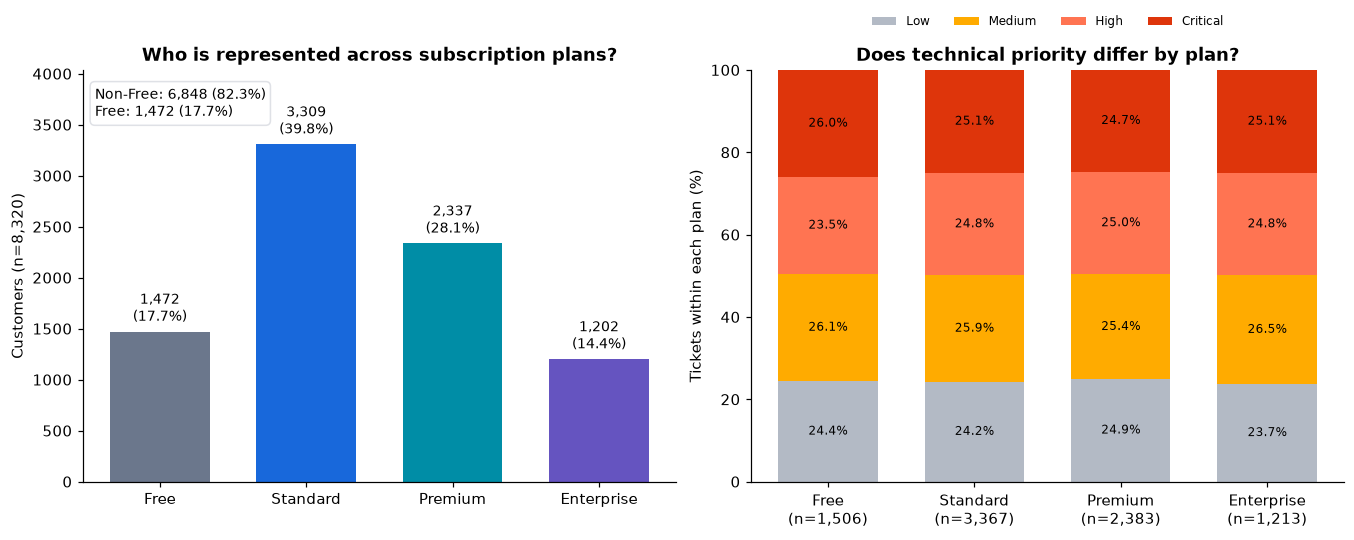

**Observed:** the dataset contains **8,320 customers**. Non-Free plans account for
**6,848/8,320 customers (82.3%)**; Standard is the largest individual plan.
Within every plan, each technical-priority category represents roughly one quarter of tickets; the largest cross-plan difference for any category is **1.5%**.

**Business meaning:** commercial plan alone does not visibly create a different technical-priority mix. This motivates checking whether another exposure measure—collaboration reach—is also absent from priority.

**Limitation:** non-Free status is only a plan proxy. The files contain no contract value, realised revenue or SLA entitlement.

In [3]:
data_overview = pd.DataFrame({
    "source": ["Customers", "Product usage", "Support tickets"],
    "row grain": ["One customer", "One customer-product-month", "One support ticket"],
    "rows": [len(customers), len(usage), len(tickets)],
})

plan_order = ["Free", "Standard", "Premium", "Enterprise"]
plan_colors = {"Free": GREY, "Standard": BLUE, "Premium": TEAL, "Enterprise": PURPLE}
priority_order = ["Low", "Medium", "High", "Critical"]
priority_colors = {"Low": "#B3BAC5", "Medium": AMBER, "High": "#FF7452", "Critical": RED}

plan_summary = customers["plan_type"].value_counts().reindex(plan_order, fill_value=0).rename("customers").to_frame()
plan_summary["share"] = plan_summary["customers"] / len(customers)
non_free_count = int(customers["plan_type"].ne("Free").sum())
free_count = int(customers["plan_type"].eq("Free").sum())

baseline_ticket_view = tickets.merge(
    customers[["customer_email", "plan_type"]],
    on="customer_email", how="left", validate="many_to_one",
)
assert len(baseline_ticket_view) == len(tickets)
priority_by_plan_count = pd.crosstab(
    baseline_ticket_view["plan_type"], baseline_ticket_view["ticket_priority"]
).reindex(index=plan_order, columns=priority_order, fill_value=0)
priority_by_plan_share = priority_by_plan_count.div(priority_by_plan_count.sum(axis=1), axis=0)

display(data_overview.style.hide(axis="index").format({"rows": "{:,}"}))
display(Markdown("**Customer plan mix**"))
display(plan_summary.style.format({"customers": "{:,}", "share": "{:.1%}"}))

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8), layout="constrained")
bars = axes[0].bar(plan_order, plan_summary["customers"], color=[plan_colors[p] for p in plan_order], width=.68)
axes[0].bar_label(
    bars,
    labels=[f"{count:,}\n({share:.1%})" for count, share in zip(plan_summary["customers"], plan_summary["share"])],
    padding=4, fontsize=9,
)
axes[0].set(
    title="Who is represented across subscription plans?",
    ylabel=f"Customers (n={len(customers):,})",
    ylim=(0, plan_summary["customers"].max() * 1.22),
)
axes[0].text(
    .02, .96,
    f"Non-Free: {non_free_count:,} ({non_free_count / len(customers):.1%})\n"
    f"Free: {free_count:,} ({free_count / len(customers):.1%})",
    transform=axes[0].transAxes, va="top", fontsize=9,
    bbox={"boxstyle": "round,pad=.35", "facecolor": "white", "edgecolor": LIGHT_GREY},
)

bottom = np.zeros(len(plan_order))
for priority in priority_order:
    values = priority_by_plan_share[priority].to_numpy() * 100
    axes[1].bar(plan_order, values, bottom=bottom, color=priority_colors[priority], label=priority, width=.68)
    for index, value in enumerate(values):
        axes[1].text(index, bottom[index] + value / 2, f"{value:.1f}%", ha="center", va="center", fontsize=8)
    bottom += values
axes[1].set(
    title="Does technical priority differ by plan?",
    ylabel="Tickets within each plan (%)", ylim=(0, 100),
    xticks=np.arange(len(plan_order)),
    xticklabels=[f"{p}\n(n={priority_by_plan_count.loc[p].sum():,})" for p in plan_order],
)
axes[1].legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(.5, 1.16), fontsize=8)
save_show(fig, "01_customer_and_queue_overview.png")

priority_spread = priority_by_plan_share.max(axis=0).sub(priority_by_plan_share.min(axis=0)).max()
display(Markdown(f"""**Observed:** the dataset contains **{len(customers):,} customers**. Non-Free plans account for
**{non_free_count:,}/{len(customers):,} customers ({non_free_count / len(customers):.1%})**; Standard is the largest individual plan.
Within every plan, each technical-priority category represents roughly one quarter of tickets; the largest cross-plan difference for any category is **{priority_spread:.1%}**.

**Business meaning:** commercial plan alone does not visibly create a different technical-priority mix. This motivates checking whether another exposure measure—collaboration reach—is also absent from priority.

**Limitation:** non-Free status is only a plan proxy. The files contain no contract value, realised revenue or SLA entitlement."""))

### How much customer-satisfaction evidence is available?

Ticket rating is easy to misread because most tickets have no rating. The next figure therefore shows the **coverage denominator first**, then the distribution of scores only among tickets that were rated.

The code also checks whether ratings appear across every ticket status. If ratings are structurally limited to closed tickets, they cannot be used as if they measured satisfaction for the full queue, and missing ratings should not be imputed as neutral or negative scores.

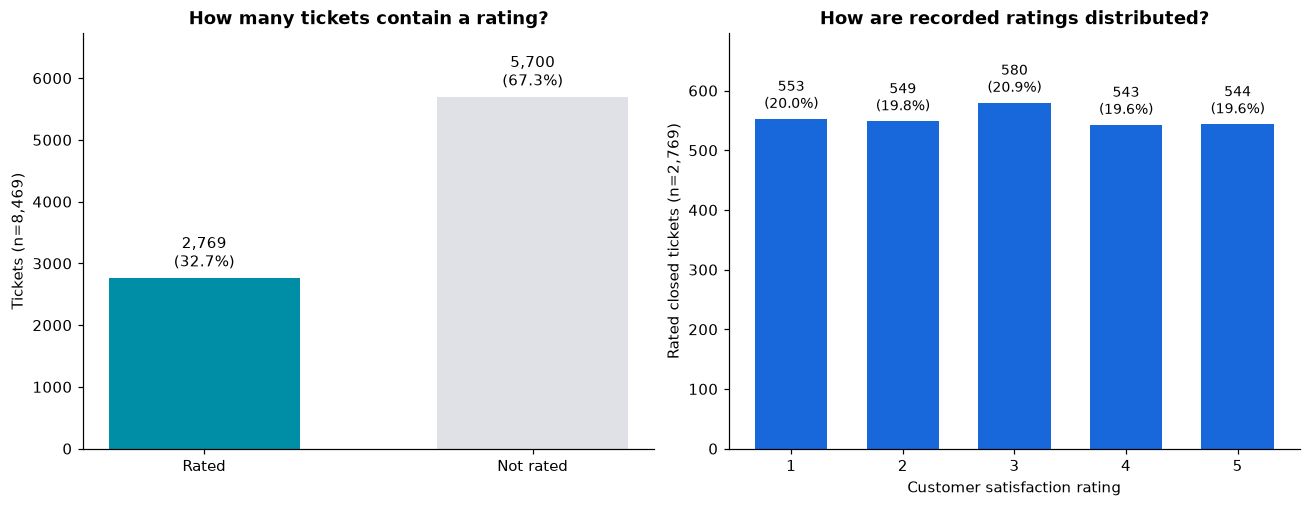

**Rating availability by ticket status**

customer_satisfaction_rating,Not rated,Rated
ticket_status,,
Closed,0,2769
Open,2819,0
Pending Customer Response,2881,0


**Observed:** only **2,769/8,469 tickets (32.7%)** are rated.
Scores 1–5 are broadly even among those rated tickets, and ratings occur only on closed tickets.

**Business meaning:** there is no dominant rating score in the observed closed-ticket feedback, but the rating field describes only a minority of the queue.

**Limitation:** rating missingness is structural, not a value to fill. This notebook therefore does not train a satisfaction model or claim that unrated tickets represent satisfied or dissatisfied customers.

In [4]:
rated_mask = tickets["customer_satisfaction_rating"].notna()
rated_count = int(rated_mask.sum())
unrated_count = int((~rated_mask).sum())
rating_counts = (
    tickets.loc[rated_mask, "customer_satisfaction_rating"]
    .astype(int).value_counts().reindex(range(1, 6), fill_value=0).sort_index()
)
rating_shares = rating_counts / rated_count
rating_status = pd.crosstab(
    tickets["ticket_status"], rated_mask.map({True: "Rated", False: "Not rated"})
)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.5), layout="constrained")
coverage_labels = ["Rated", "Not rated"]
coverage_values = [rated_count, unrated_count]
coverage_bars = axes[0].bar(coverage_labels, coverage_values, color=[TEAL, LIGHT_GREY], width=.58)
axes[0].bar_label(
    coverage_bars,
    labels=[f"{value:,}\n({value / len(tickets):.1%})" for value in coverage_values], padding=4,
)
axes[0].set(
    title="How many tickets contain a rating?",
    ylabel=f"Tickets (n={len(tickets):,})", ylim=(0, max(coverage_values) * 1.18),
)

rating_bars = axes[1].bar(rating_counts.index.astype(str), rating_counts.values, color=BLUE, width=.65)
axes[1].bar_label(
    rating_bars,
    labels=[f"{count:,}\n({share:.1%})" for count, share in zip(rating_counts, rating_shares)],
    padding=4, fontsize=9,
)
axes[1].set(
    title="How are recorded ratings distributed?",
    xlabel="Customer satisfaction rating", ylabel=f"Rated closed tickets (n={rated_count:,})",
    ylim=(0, rating_counts.max() * 1.20),
)
save_show(fig, "02_rating_overview.png")

display(Markdown("**Rating availability by ticket status**"))
display(rating_status)
ratings_only_closed = tickets.loc[rated_mask, "ticket_status"].eq("Closed").all()
display(Markdown(f"""**Observed:** only **{rated_count:,}/{len(tickets):,} tickets ({rated_count / len(tickets):.1%})** are rated.
Scores 1–5 are broadly even among those rated tickets, and ratings {'occur only on closed tickets' if ratings_only_closed else 'appear across multiple statuses'}.

**Business meaning:** there is no dominant rating score in the observed closed-ticket feedback, but the rating field describes only a minority of the queue.

**Limitation:** rating missingness is structural, not a value to fill. This notebook therefore does not train a satisfaction model or claim that unrated tickets represent satisfied or dissatisfied customers."""))

## 3. How did we identify the problem?

The story is selected from exploratory evidence rather than assumed in advance.

For each customer, `max_collaborators` is the largest collaborator count observed across products and months. This represents the greatest observed collaboration reach. `mean_collaborators` is retained later as a sensitivity check.

### What the first EDA cell does

1. Aggregates the 42,210 monthly usage rows to one row per customer.
2. Joins customer plan information at one-to-one grain.
3. Joins the aggregated customer measure to tickets using a validated many-to-one join.
4. Creates exact collaborator-count summaries.
5. Plots the distribution and marks 18 and 20 as candidate policy boundaries.

**Why it matters:** the proposed tiers are only useful if the data contains a meaningful high-collaboration tail with enough observations to analyse.

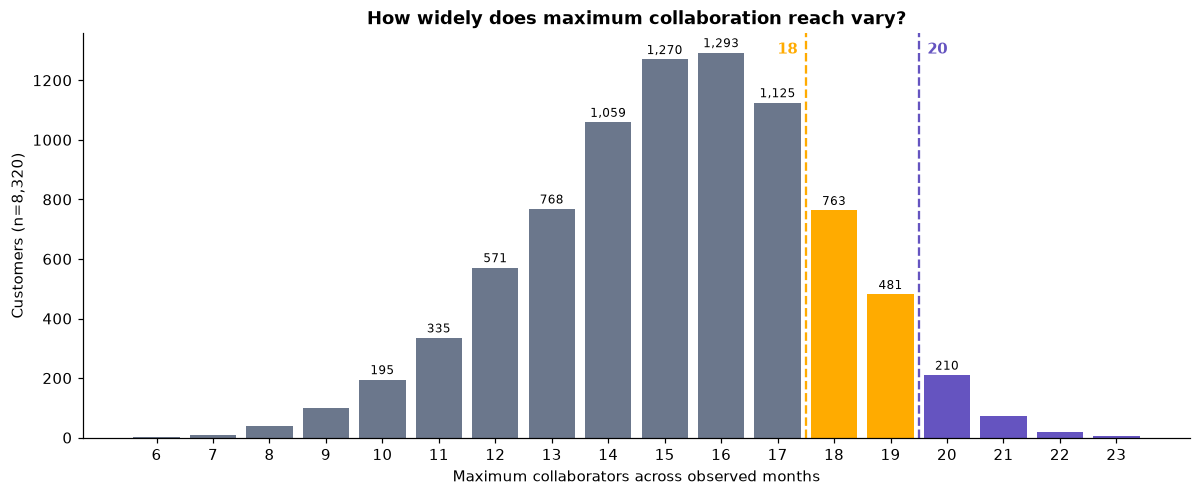

**Observed:** maximum reach spans **6 to 23 collaborators**. **Meaning:** the data contains typical customers and a small high-reach tail. **Limitation:** this is a maximum monthly count, not a live network size.

In [5]:
usage_customer = usage.groupby("customer_id", as_index=False).agg(
    max_collaborators=("collaborators", "max"),
    mean_collaborators=("collaborators", "mean"),
    usage_rows=("collaborators", "size"),
)
customer_view = customers.merge(
    usage_customer, on="customer_id", how="left", validate="one_to_one"
)
assert len(customer_view) == len(customers)
assert customer_view["max_collaborators"].notna().all()
customer_view["non_free_plan"] = customer_view["plan_type"].ne("Free")

ticket_view = tickets.merge(
    customer_view[[
        "customer_email", "customer_id", "plan_type", "company_size",
        "max_collaborators", "mean_collaborators", "non_free_plan",
    ]],
    on="customer_email", how="left", validate="many_to_one",
)
assert len(ticket_view) == len(tickets)
assert ticket_view["customer_id"].notna().all()
ticket_view["high_priority"] = ticket_view["ticket_priority"].isin(["High", "Critical"])

exact_customer = customer_view.groupby("max_collaborators").agg(
    customers=("customer_id", "size"),
    non_free_rate=("non_free_plan", "mean"),
)
exact_ticket = ticket_view.groupby("max_collaborators").agg(
    tickets=("ticket_id", "size"),
    high_priority_rate=("high_priority", "mean"),
)
exact_reach = exact_customer.join(exact_ticket)

fig, ax = plt.subplots(figsize=(10.8, 4.4), layout="constrained")
colors = [GREY if reach <= 17 else AMBER if reach <= 19 else PURPLE for reach in exact_customer.index]
bars = ax.bar(exact_customer.index, exact_customer["customers"], color=colors, width=.82)
for bar, value in zip(bars, exact_customer["customers"]):
    if value >= 100:
        ax.text(bar.get_x() + bar.get_width()/2, value + 18, f"{value:,}", ha="center", fontsize=8)
ax.axvline(17.5, color=AMBER, linestyle="--", linewidth=1.5)
ax.axvline(19.5, color=PURPLE, linestyle="--", linewidth=1.5)
ax.text(17.35, ax.get_ylim()[1] * .95, "18", color=AMBER, ha="right", fontweight="bold")
ax.text(19.65, ax.get_ylim()[1] * .95, "20", color=PURPLE, ha="left", fontweight="bold")
ax.set(
    title="How widely does maximum collaboration reach vary?",
    xlabel="Maximum collaborators across observed months",
    ylabel=f"Customers (n={len(customer_view):,})",
)
ax.set_xticks(exact_customer.index)
save_show(fig, "03_collaboration_distribution.png")

display(Markdown(
    f"**Observed:** maximum reach spans **{int(exact_customer.index.min())} to "
    f"{int(exact_customer.index.max())} collaborators**. "
    f"**Meaning:** the data contains typical customers and a small high-reach tail. "
    f"**Limitation:** this is a maximum monthly count, not a live network size."
))

### Compare the two sides of the proposed blind spot

The next figure compares two rates at each exact collaborator count:

- **commercial-plan concentration:** customers on any plan other than Free;
- **existing priority recognition:** tickets currently labelled High or Critical.

Point size represents the denominator. Grey points have fewer than 50 observations and are visually separated because their percentages can change sharply from only a few records.

**Decision logic:** if both lines rise together, the current priority system may already account for collaboration. If non-Free concentration rises while priority remains flat, the proposed blind spot remains plausible.

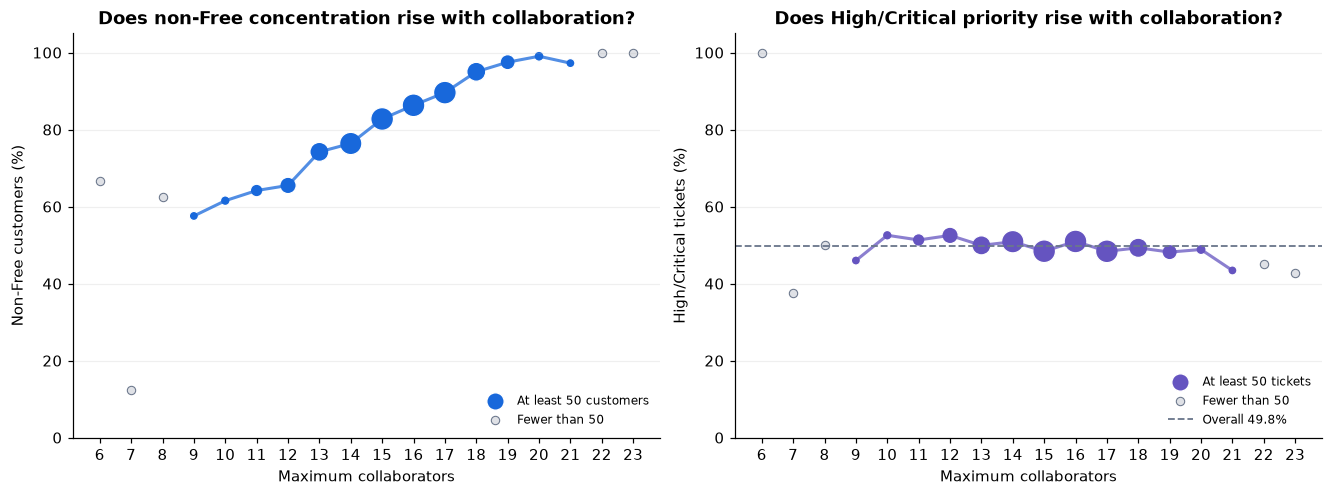

**Observed:** from 17 to 20 maximum collaborators, non-Free share rises from
**89.6% (n=1,125)** to
**99.0% (n=210)**. High/Critical share is
**48.4% (n=1,153)** and
**48.9% (n=219)**, respectively.

**Meaning:** commercial concentration rises sharply, while technical priority remains near the overall rate.
That mismatch is why Blast Radius was selected.

**Reading the chart:** point size represents the customer or ticket denominator.

**Limitation:** grey points contain fewer than 50 observations and are not stable evidence.

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), layout="constrained")
stable_customer = exact_reach["customers"] >= 50
stable_ticket = exact_reach["tickets"] >= 50

axes[0].plot(
    exact_reach.index[stable_customer],
    exact_reach.loc[stable_customer, "non_free_rate"] * 100,
    color=BLUE, linewidth=2, alpha=.75,
)
axes[0].scatter(
    exact_reach.index[stable_customer],
    exact_reach.loc[stable_customer, "non_free_rate"] * 100,
    s=np.clip(exact_reach.loc[stable_customer, "customers"] / 5, 35, 220),
    color=BLUE, edgecolor="white", linewidth=.8, label="At least 50 customers",
)
axes[0].scatter(
    exact_reach.index[~stable_customer],
    exact_reach.loc[~stable_customer, "non_free_rate"] * 100,
    s=30, color=LIGHT_GREY, edgecolor=GREY, linewidth=.7, label="Fewer than 50",
)
axes[0].set(
    title="Does non-Free concentration rise with collaboration?",
    xlabel="Maximum collaborators", ylabel="Non-Free customers (%)", ylim=(0, 105),
)

axes[1].plot(
    exact_reach.index[stable_ticket],
    exact_reach.loc[stable_ticket, "high_priority_rate"] * 100,
    color=PURPLE, linewidth=2, alpha=.75,
)
axes[1].scatter(
    exact_reach.index[stable_ticket],
    exact_reach.loc[stable_ticket, "high_priority_rate"] * 100,
    s=np.clip(exact_reach.loc[stable_ticket, "tickets"] / 5, 35, 220),
    color=PURPLE, edgecolor="white", linewidth=.8, label="At least 50 tickets",
)
axes[1].scatter(
    exact_reach.index[~stable_ticket],
    exact_reach.loc[~stable_ticket, "high_priority_rate"] * 100,
    s=30, color=LIGHT_GREY, edgecolor=GREY, linewidth=.7, label="Fewer than 50",
)
overall_priority_rate = ticket_view["high_priority"].mean()
axes[1].axhline(
    overall_priority_rate * 100, color=GREY, linestyle="--", linewidth=1.2,
    label=f"Overall {overall_priority_rate:.1%}",
)
axes[1].set(
    title="Does High/Critical priority rise with collaboration?",
    xlabel="Maximum collaborators", ylabel="High/Critical tickets (%)", ylim=(0, 105),
)
for ax in axes:
    ax.set_xticks(exact_reach.index)
    ax.grid(axis="y", alpha=.2)
    ax.legend(frameon=False, fontsize=8, loc="lower right")
save_show(fig, "04_problem_discovery.png")

reach_17 = exact_reach.loc[17]
reach_20 = exact_reach.loc[20]
display(Markdown(f'''**Observed:** from 17 to 20 maximum collaborators, non-Free share rises from
**{reach_17.non_free_rate:.1%} (n={int(reach_17.customers):,})** to
**{reach_20.non_free_rate:.1%} (n={int(reach_20.customers):,})**. High/Critical share is
**{reach_17.high_priority_rate:.1%} (n={int(reach_17.tickets):,})** and
**{reach_20.high_priority_rate:.1%} (n={int(reach_20.tickets):,})**, respectively.

**Meaning:** commercial concentration rises sharply, while technical priority remains near the overall rate.
That mismatch is why Blast Radius was selected.

**Reading the chart:** point size represents the customer or ticket denominator.

**Limitation:** grey points contain fewer than 50 observations and are not stable evidence.'''))

## 4. Measuring collaboration reach

EDA shows the raw relationship, but routing needs transparent and repeatable features.

### How the features work

- `max_collaborators` captures the largest observed reach and is the primary routing feature.
- `mean_collaborators` tests whether the conclusion depends on using a maximum.
- `collaboration_tier` converts reach into Standard (≤17), Elevated (18-19) and Hub (≥20).
- `non_free_plan` is the customer-level target used to test commercial concentration.
- `high_priority` is the ticket-level target used to test whether priority already reflects reach.

The terms Standard, Elevated and Hub describe collaboration exposure, not technical severity. The thresholds are policy coverage bands that create a small pilot population; they are not natural clusters discovered by an algorithm.

### What the next cell does

It engineers these five fields, reattaches the tier to tickets without multiplying rows, displays a feature dictionary and compares the observed tier rates. The percentages include denominators so the Hub result cannot be mistaken for a population-wide rate.

### What this notebook deliberately does not engineer

This section **is feature engineering**, but it is intentionally small. Sessions, integrations and action-rate composites are excluded from the current model because they answer broader questions and would require either arbitrary weights or reliable ticket timing. After ticket creation time is collected, sessions and active days can become prospective before/after outcomes rather than ingredients chosen to strengthen a story.


feature,definition,role
max_collaborators,Largest monthly collaborator count observed for a customer,Primary reach feature
mean_collaborators,Average collaborator count across observed usage rows,Sensitivity check
collaboration_tier,Standard ≤17; Elevated 18-19; Hub ≥20,Routing coverage band
non_free_plan,Plan is not Free; commercial-plan proxy only,Customer-model target
high_priority,Ticket priority is High or Critical,Ticket-model target


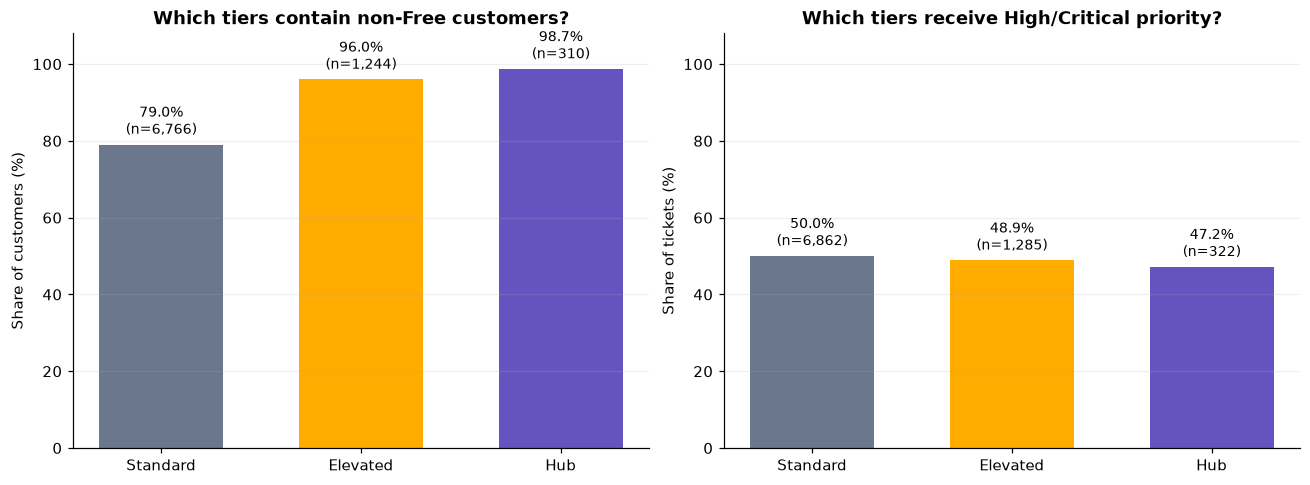

,customers,non_free_rate,customer_share
collaboration_tier,,,
Standard,"6,766",79.0%,81.3%
Elevated,"1,244",96.0%,15.0%
Hub,310,98.7%,3.7%


**Observed:** Hub contains **310
customers (3.7%)** and
**98.7%** are non-Free. Yet only
**47.2% of Hub tickets
(n=322)** are High/Critical.

**Meaning:** the tier summary preserves the mismatch and defines a manageable simulation population.

**Limitation:** non-Free is a commercial-plan proxy; the data contains no contract value or revenue.

In [7]:
customer_view["collaboration_tier"] = pd.cut(
    customer_view["max_collaborators"],
    bins=[-np.inf, 17, 19, np.inf],
    labels=TIER_ORDER, ordered=True,
)
customer_view["collaboration_tier_code"] = customer_view["collaboration_tier"].cat.codes
ticket_view = ticket_view.merge(
    customer_view[["customer_id", "collaboration_tier", "collaboration_tier_code"]],
    on="customer_id", how="left", validate="many_to_one",
)
assert len(ticket_view) == len(tickets)

feature_dictionary = pd.DataFrame({
    "feature": [
        "max_collaborators", "mean_collaborators", "collaboration_tier",
        "non_free_plan", "high_priority",
    ],
    "definition": [
        "Largest monthly collaborator count observed for a customer",
        "Average collaborator count across observed usage rows",
        "Standard ≤17; Elevated 18-19; Hub ≥20",
        "Plan is not Free; commercial-plan proxy only",
        "Ticket priority is High or Critical",
    ],
    "role": [
        "Primary reach feature", "Sensitivity check", "Routing coverage band",
        "Customer-model target", "Ticket-model target",
    ],
})
display(feature_dictionary.style.hide(axis="index"))

tier_customer = customer_view.groupby("collaboration_tier", observed=True).agg(
    customers=("customer_id", "size"),
    non_free_rate=("non_free_plan", "mean"),
).reindex(TIER_ORDER)
tier_customer["customer_share"] = tier_customer["customers"] / len(customer_view)
tier_ticket = ticket_view.groupby("collaboration_tier", observed=True).agg(
    tickets=("ticket_id", "size"),
    high_priority_rate=("high_priority", "mean"),
).reindex(TIER_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.3), layout="constrained")
panels = [
    (axes[0], tier_customer["non_free_rate"], tier_customer["customers"],
     "Which tiers contain non-Free customers?", "Customers"),
    (axes[1], tier_ticket["high_priority_rate"], tier_ticket["tickets"],
     "Which tiers receive High/Critical priority?", "Tickets"),
]
for ax, rates, denominators, title, denominator_name in panels:
    bars = ax.bar(
        TIER_ORDER, rates * 100,
        color=[TIER_COLORS[tier] for tier in TIER_ORDER], width=.62,
    )
    labels = [f"{rate:.1%}\n(n={int(n):,})" for rate, n in zip(rates, denominators)]
    ax.bar_label(bars, labels=labels, padding=4, fontsize=9)
    ax.set(
        title=title, ylabel=f"Share of {denominator_name.lower()} (%)", ylim=(0, 108)
    )
    ax.grid(axis="y", alpha=.2)
save_show(fig, "05_tier_relationships.png")
display(tier_customer.style.format({
    "customers": "{:,}", "non_free_rate": "{:.1%}", "customer_share": "{:.1%}"
}))

display(Markdown(f'''**Observed:** Hub contains **{int(tier_customer.loc["Hub", "customers"]):,}
customers ({tier_customer.loc["Hub", "customer_share"]:.1%})** and
**{tier_customer.loc["Hub", "non_free_rate"]:.1%}** are non-Free. Yet only
**{tier_ticket.loc["Hub", "high_priority_rate"]:.1%} of Hub tickets
(n={int(tier_ticket.loc["Hub", "tickets"]):,})** are High/Critical.

**Meaning:** the tier summary preserves the mismatch and defines a manageable simulation population.

**Limitation:** non-Free is a commercial-plan proxy; the data contains no contract value or revenue.'''))

## 5. Why these models, and what do they test?

The analysis uses two one-feature logistic regressions as **diagnostic checks**, not as a ticket-routing model.

| Question | Row grain | Input | Binary outcome | What a useful result would mean |
|---|---|---|---|---|
| Does collaboration identify commercial-plan concentration? | One customer | Maximum collaborators | Non-Free plan | Higher collaboration ranks non-Free customers above Free customers more often |
| Does current priority already recognise collaboration? | One ticket | Maximum collaborators | High/Critical priority | Higher collaboration ranks High/Critical tickets above Low/Medium tickets more often |

### Why logistic regression?

Logistic regression translates collaborator count into the probability of a binary outcome. Its coefficient direction is readable, and out-of-fold AUC tests ranking without choosing an arbitrary probability threshold. AUC of 0.500 is no better than random ranking.

### Why not a more complex model?

- **K-means** has no outcome and would create clusters without answering either business question.
- **Random forest** adds opacity to a one-input relationship check without solving a richer prediction problem.
- **Churn modelling** is unsupported because no churn label exists.
- **A weighted Blast Radius score** would require unvalidated weights across collaborators, integrations and velocity.
- **Training on a proposed new queue label** would be circular because that label would be invented by the policy itself.

### How training and tuning work

`StandardScaler` puts collaborator values on a standard-deviation scale inside each training fold. Logistic `C` controls regularisation: smaller values shrink the relationship more strongly. The next cell compares only `C = 0.01, 0.1, 1, 10` and maximum versus mean collaborators; this is a stability check, not a search for the most persuasive result.

The customer model uses five stratified folds. The ticket model uses five customer-grouped folds so tickets from the same customer never appear in both training and validation. The models do not assign queue priority; they decide whether the evidence chain is strong enough to justify a small policy simulation.

In [8]:
def cross_validated_logit(frame, feature, target, splitter, C=1.0, groups=None):
    X = frame[[feature]].to_numpy()
    y = frame[target].astype(int).to_numpy()
    oof = np.full(len(frame), np.nan)
    fold_rows = []
    split_iter = splitter.split(X, y, groups) if groups is not None else splitter.split(X, y)
    for fold, (train_idx, test_idx) in enumerate(split_iter, start=1):
        model = make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=2000))
        model.fit(X[train_idx], y[train_idx])
        prediction = model.predict_proba(X[test_idx])[:, 1]
        oof[test_idx] = prediction
        coefficient = model.named_steps["logisticregression"].coef_[0, 0]
        fold_rows.append({
            "fold": fold,
            "auc": roc_auc_score(y[test_idx], prediction),
            "brier": brier_score_loss(y[test_idx], prediction),
            "standardised_coefficient": coefficient,
        })
    folds = pd.DataFrame(fold_rows)
    summary = {
        "auc": roc_auc_score(y, oof),
        "fold_auc_sd": folds["auc"].std(ddof=1),
        "brier": brier_score_loss(y, oof),
        "coefficient": folds["standardised_coefficient"].mean(),
        "odds_ratio_per_sd": np.exp(folds["standardised_coefficient"].mean()),
    }
    return summary, folds, oof

customer_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ticket_splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

c_rows = []
for C in [0.01, 0.1, 1, 10]:
    commercial, _, _ = cross_validated_logit(
        customer_view, "max_collaborators", "non_free_plan", customer_splitter, C=C
    )
    priority, _, _ = cross_validated_logit(
        ticket_view, "max_collaborators", "high_priority", ticket_splitter,
        C=C, groups=ticket_view["customer_id"],
    )
    c_rows.append({
        "C": C, "commercial AUC": commercial["auc"],
        "commercial Brier": commercial["brier"], "priority AUC": priority["auc"],
    })
c_sensitivity = pd.DataFrame(c_rows).set_index("C")
default_stable = (
    c_sensitivity.loc[1, "commercial AUC"] >= c_sensitivity["commercial AUC"].max() - .005
    and c_sensitivity.loc[1, "commercial Brier"] <= c_sensitivity["commercial Brier"].min() + .002
    and c_sensitivity.loc[1, "priority AUC"] >= c_sensitivity["priority AUC"].max() - .005
)
selected_C = 1.0 if default_stable else float(c_sensitivity["commercial Brier"].idxmin())

feature_rows = []
for feature in ["max_collaborators", "mean_collaborators"]:
    result, _, _ = cross_validated_logit(
        customer_view, feature, "non_free_plan", customer_splitter, C=selected_C
    )
    feature_rows.append({
        "feature": feature, "AUC": result["auc"],
        "fold AUC SD": result["fold_auc_sd"], "Brier": result["brier"],
    })
feature_sensitivity = pd.DataFrame(feature_rows).set_index("feature")
selected_feature = (
    "max_collaborators"
    if feature_sensitivity.loc["max_collaborators", "AUC"]
    >= feature_sensitivity["AUC"].max() - .02
    else feature_sensitivity["AUC"].idxmax()
)
display(Markdown("**Regularisation sensitivity**"))
display(c_sensitivity.style.format("{:.3f}"))
display(Markdown("**Maximum versus mean collaborator count**"))
display(feature_sensitivity.style.format("{:.3f}"))
print(f"Selected C={selected_C:g}; selected customer feature={selected_feature}.")

**Regularisation sensitivity**

,commercial AUC,commercial Brier,priority AUC
C,,,
0.010000,0.704,0.135,0.509
0.100000,0.704,0.135,0.509
1.000000,0.704,0.135,0.509
10.000000,0.704,0.135,0.509


**Maximum versus mean collaborator count**

,AUC,fold AUC SD,Brier
feature,,,
max_collaborators,0.704,0.022,0.135
mean_collaborators,0.712,0.028,0.132


Selected C=1; selected customer feature=max_collaborators.


### Validate the selected specification

The next cell produces predictions only for records held out from model training.

**ROC AUC interpretation:**

- 0.500 means the feature has no useful ranking ability;
- values above 0.500 show increasing separation;
- fold variation shows whether the result depends heavily on one split.

The left panel compares the commercial and existing-priority relationships. The right panel checks whether maximum reach performs similarly to mean reach. Maximum reach remains preferable when performance is similar because the routing question concerns the largest potential collaboration exposure.

**Business use:** these models test the evidence chain. They do not learn an invented “ideal” queue and they do not assign the proposed priority uplift.

,grain,positive / total,auc,fold_auc_sd,brier,coefficient,odds_ratio_per_sd
question,,,,,,,
Non-Free plan relationship,customer,"6,848 / 8,320",0.704,0.022,0.135,+0.746,2.11
High/Critical priority relationship,ticket,"4,214 / 8,469",0.509,0.014,0.250,-0.037,0.96


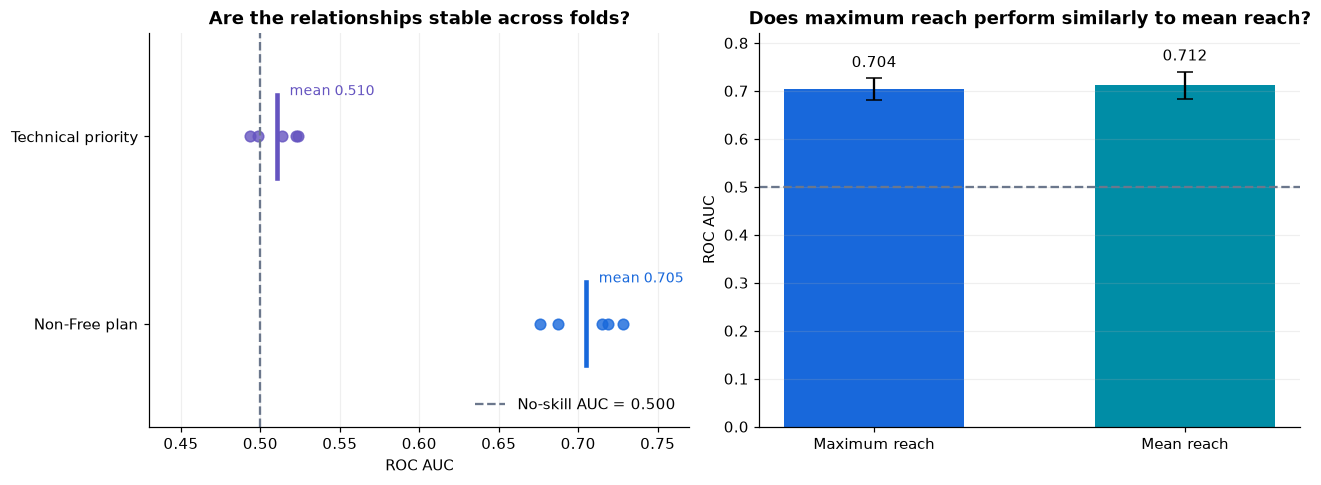

**Observed:** the commercial-plan relationship reaches **0.704 AUC**
with fold SD **0.022**. Existing priority reaches
**0.509 grouped AUC** with fold SD **0.014**.

**Meaning:** Collaboration has a usable association with the non-Free plan proxy. Existing priority shows little ability to distinguish collaboration reach.

**Limitation:** these retrospective models diagnose relationships. They do not forecast service outcomes,
assign the new queue or estimate revenue.

In [9]:
commercial_result, commercial_folds, customer_oof = cross_validated_logit(
    customer_view, selected_feature, "non_free_plan", customer_splitter, C=selected_C
)
priority_result, priority_folds, ticket_oof = cross_validated_logit(
    ticket_view, "max_collaborators", "high_priority", ticket_splitter,
    C=selected_C, groups=ticket_view["customer_id"],
)
model_summary = pd.DataFrame([
    {
        "question": "Non-Free plan relationship", "grain": "customer",
        "positive / total": f"{customer_view.non_free_plan.sum():,} / {len(customer_view):,}",
        **commercial_result,
    },
    {
        "question": "High/Critical priority relationship", "grain": "ticket",
        "positive / total": f"{ticket_view.high_priority.sum():,} / {len(ticket_view):,}",
        **priority_result,
    },
]).set_index("question")
display(model_summary.style.format({
    "auc": "{:.3f}", "fold_auc_sd": "{:.3f}", "brier": "{:.3f}",
    "coefficient": "{:+.3f}", "odds_ratio_per_sd": "{:.2f}",
}))

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.3), layout="constrained")
fold_plot = pd.concat([
    commercial_folds.assign(model="Non-Free plan"),
    priority_folds.assign(model="Technical priority"),
])
for index, (model_name, group) in enumerate(fold_plot.groupby("model", sort=False)):
    color = [BLUE, PURPLE][index]
    axes[0].scatter(group["auc"], np.full(len(group), index), color=color, s=48, alpha=.8)
    mean_auc = group["auc"].mean()
    axes[0].plot([mean_auc, mean_auc], [index - .22, index + .22], color=color, linewidth=3)
    axes[0].text(mean_auc + .008, index + .22, f"mean {mean_auc:.3f}", color=color, fontsize=9)
axes[0].axvline(.5, color=GREY, linestyle="--", linewidth=1.5, label="No-skill AUC = 0.500")
axes[0].set(
    title="Are the relationships stable across folds?", xlabel="ROC AUC",
    yticks=[0, 1], yticklabels=["Non-Free plan", "Technical priority"],
    xlim=(.43, .77), ylim=(-.55, 1.55),
)
axes[0].grid(axis="x", alpha=.2)
axes[0].legend(frameon=False, loc="lower right")

bars = axes[1].bar(
    ["Maximum reach", "Mean reach"], feature_sensitivity["AUC"],
    yerr=feature_sensitivity["fold AUC SD"],
    color=[BLUE, TEAL], capsize=5, width=.58,
)
axes[1].bar_label(
    bars, labels=[f"{value:.3f}" for value in feature_sensitivity["AUC"]], padding=5
)
axes[1].axhline(.5, color=GREY, linestyle="--", linewidth=1.5)
axes[1].set(
    title="Does maximum reach perform similarly to mean reach?",
    ylabel="ROC AUC", ylim=(0, .82),
)
axes[1].grid(axis="y", alpha=.2)
save_show(fig, "06_model_validation.png")

commercial_auc = commercial_result["auc"]
priority_auc = priority_result["auc"]
commercial_gate = (
    "Collaboration has a usable association with the non-Free plan proxy."
    if commercial_auc >= .60 else "The commercial-concentration claim is not supported."
)
if priority_auc >= .60:
    priority_gate = "Existing priority already reflects collaboration enough to reject the blind-spot claim."
elif priority_auc <= .55:
    priority_gate = "Existing priority shows little ability to distinguish collaboration reach."
else:
    priority_gate = "The priority relationship is ambiguous."

display(Markdown(f'''**Observed:** the commercial-plan relationship reaches **{commercial_auc:.3f} AUC**
with fold SD **{commercial_result["fold_auc_sd"]:.3f}**. Existing priority reaches
**{priority_auc:.3f} grouped AUC** with fold SD **{priority_result["fold_auc_sd"]:.3f}**.

**Meaning:** {commercial_gate} {priority_gate}

**Limitation:** these retrospective models diagnose relationships. They do not forecast service outcomes,
assign the new queue or estimate revenue.'''))

## 6. What would the routing change?

The model diagnoses a gap; the routing rule translates that gap into an operational proposal.

### Proposed rule

- Hub + Premium/Enterprise + Low → Medium pilot queue;
- Hub + Premium/Enterprise + Medium → High pilot queue;
- Elevated → visible collaboration flag only;
- Standard and existing High/Critical tickets → no change.

For example, a technically Medium ticket remains **Medium severity**, but its effective pilot queue becomes **High** when it belongs to an eligible Hub customer.

### What the next cell does

It copies technical priority into an effective queue field, applies only the two permitted one-level moves, and counts the resulting workload by priority, plan and ticket type.

**How to interpret it:** this is a feasibility simulation. A moved ticket is not evidence of faster service, higher engagement or additional revenue.

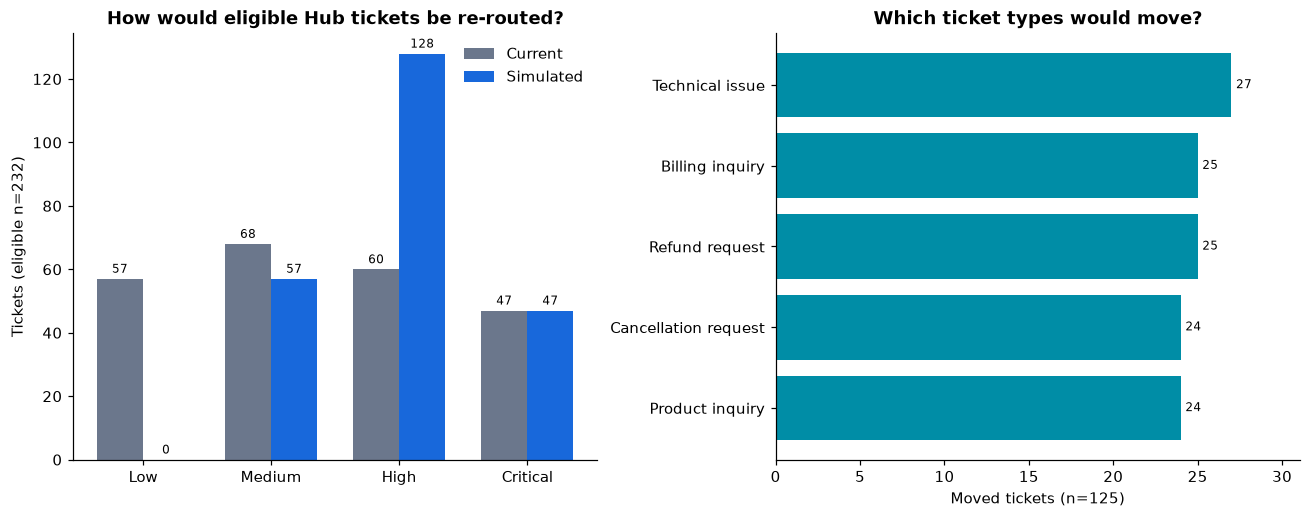

**Moved tickets by plan and original priority**

ticket_priority,Low,Medium
plan_type,,
Premium,34,30
Enterprise,23,38


**Overall queue composition**

,current,simulated,change
Low,2063,2006,-57
Medium,2192,2181,-11
High,2085,2153,68
Critical,2129,2129,0


**Observed:** the rule moves **125/8,469 tickets
(1.48%)**. Existing Critical tickets are unchanged.

**Meaning:** the policy is narrow enough for a controlled pilot rather than a full queue redesign.

**Limitation:** movement is not improvement. The data does not show how waiting time or engagement
would respond.

In [10]:
priority_order = ["Low", "Medium", "High", "Critical"]
ticket_view["effective_priority"] = ticket_view["ticket_priority"]
eligible = (
    ticket_view["collaboration_tier"].eq("Hub")
    & ticket_view["plan_type"].isin(["Premium", "Enterprise"])
    & ticket_view["ticket_priority"].isin(["Low", "Medium"])
)
ticket_view.loc[
    eligible & ticket_view["ticket_priority"].eq("Low"), "effective_priority"
] = "Medium"
ticket_view.loc[
    eligible & ticket_view["ticket_priority"].eq("Medium"), "effective_priority"
] = "High"
ticket_view["moved"] = ticket_view["effective_priority"].ne(ticket_view["ticket_priority"])

eligible_population = ticket_view[
    ticket_view["collaboration_tier"].eq("Hub")
    & ticket_view["plan_type"].isin(["Premium", "Enterprise"])
]
queue_composition = pd.DataFrame({
    "current": ticket_view["ticket_priority"].value_counts().reindex(priority_order, fill_value=0),
    "simulated": ticket_view["effective_priority"].value_counts().reindex(priority_order, fill_value=0),
})
queue_composition["change"] = queue_composition["simulated"] - queue_composition["current"]
moved_by_plan_priority = (
    ticket_view.loc[eligible]
    .groupby(["plan_type", "ticket_priority"], observed=True).size()
    .unstack(fill_value=0)
    .reindex(index=["Premium", "Enterprise"], columns=["Low", "Medium"], fill_value=0)
)
moved_by_type = ticket_view.loc[eligible, "ticket_type"].value_counts().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.6), layout="constrained")
current_eligible = eligible_population["ticket_priority"].value_counts().reindex(priority_order, fill_value=0)
simulated_eligible = eligible_population["effective_priority"].value_counts().reindex(priority_order, fill_value=0)
x = np.arange(len(priority_order))
width = .36
current_bars = axes[0].bar(x - width/2, current_eligible, width, color=GREY, label="Current")
simulated_bars = axes[0].bar(x + width/2, simulated_eligible, width, color=BLUE, label="Simulated")
axes[0].bar_label(current_bars, padding=2, fontsize=8)
axes[0].bar_label(simulated_bars, padding=2, fontsize=8)
axes[0].set(
    title="How would eligible Hub tickets be re-routed?",
    ylabel=f"Tickets (eligible n={len(eligible_population):,})",
    xticks=x, xticklabels=priority_order,
)
axes[0].legend(frameon=False)

bars = axes[1].barh(moved_by_type.index, moved_by_type.values, color=TEAL)
axes[1].bar_label(bars, padding=3, fontsize=8)
axes[1].set(
    title="Which ticket types would move?",
    xlabel=f"Moved tickets (n={eligible.sum():,})",
)
axes[1].margins(x=.15)
save_show(fig, "07_routing_simulation.png")

display(Markdown("**Moved tickets by plan and original priority**"))
display(moved_by_plan_priority)
display(Markdown("**Overall queue composition**"))
display(queue_composition)

moved_count = int(ticket_view["moved"].sum())
moved_share = moved_count / len(ticket_view)
display(Markdown(f'''**Observed:** the rule moves **{moved_count:,}/{len(ticket_view):,} tickets
({moved_share:.2%})**. Existing Critical tickets are unchanged.

**Meaning:** the policy is narrow enough for a controlled pilot rather than a full queue redesign.

**Limitation:** movement is not improvement. The data does not show how waiting time or engagement
would respond.'''))

## 7. Is the proposal ready for a pilot?

This section now runs, but it does **not** pretend to run an A/B test. It checks whether the supplied schema contains the fields required to evaluate one.

### What the readiness code checks

1. Whether a historical cohort matches the proposed routing rule.
2. Whether a stable customer key exists for treatment/control assignment.
3. Whether ticket creation time exists to start the response-time clock.
4. Whether first-response duration can be calculated.
5. Whether monthly product usage can be aligned before and after a ticket.
6. Whether historical treatment assignment exists.

### How product sessions would be used

The usage table records `sessions` once per customer-product-month. Sessions are meaningful as a **future secondary outcome**: compare post-ticket session stability between treatment and control customers. They are not used as a current outcome because there is no ticket-creation timestamp to define which months are before or after each ticket.

In [11]:
ticket_columns = set(tickets.columns)
usage_columns = set(usage.columns)
has_customer_key = "customer_id" in ticket_view.columns and ticket_view["customer_id"].notna().all()
ticket_created_candidates = {"ticket_created_at", "ticket_creation_time", "created_at", "ticket_date"}
has_ticket_created_at = bool(ticket_columns.intersection(ticket_created_candidates))
has_first_response_timestamp = (
    "first_response_time" in ticket_columns and tickets["first_response_time"].notna().any()
)
can_measure_first_response = has_ticket_created_at and has_first_response_timestamp
has_usage_month = "month" in usage_columns
can_align_post_ticket_engagement = has_ticket_created_at and has_usage_month
treatment_candidates = {"treatment", "experiment_group", "routing_policy"}
has_historical_treatment = bool(ticket_columns.intersection(treatment_candidates))

pilot_readiness = pd.DataFrame({
    "requirement": [
        "Historical tickets matching the proposed rule",
        "Customer-level randomisation key",
        "Ticket creation timestamp",
        "First-response interval",
        "Post-ticket engagement alignment",
        "Historical treatment assignment",
    ],
    "status": [
        f"Available: {moved_count:,} tickets",
        "Available" if has_customer_key else "Missing",
        "Available" if has_ticket_created_at else "Missing",
        "Measurable" if can_measure_first_response else "Blocked",
        "Measurable" if can_align_post_ticket_engagement else "Blocked",
        "Available" if has_historical_treatment else "Not present",
    ],
    "consequence": [
        "Queue workload can be simulated",
        "A future pilot can randomise by customer",
        "Required to start the response-time clock",
        "Cannot evaluate the primary service KPI",
        "Cannot define before/after usage around a ticket",
        "No historical causal comparison is possible",
    ],
})
display(pilot_readiness.style.hide(axis="index"))

impact_ready = has_customer_key and can_measure_first_response and can_align_post_ticket_engagement
readiness_message = (
    "The supplied data can evaluate the pilot."
    if impact_ready
    else "Routing workload can be simulated, but impact evaluation is blocked by missing ticket-creation timing."
)
display(Markdown(f"**Readiness result:** {readiness_message}"))

requirement,status,consequence
Historical tickets matching the proposed rule,Available: 125 tickets,Queue workload can be simulated
Customer-level randomisation key,Available,A future pilot can randomise by customer
Ticket creation timestamp,Missing,Required to start the response-time clock
First-response interval,Blocked,Cannot evaluate the primary service KPI
Post-ticket engagement alignment,Blocked,Cannot define before/after usage around a ticket
Historical treatment assignment,Not present,No historical causal comparison is possible


**Readiness result:** Routing workload can be simulated, but impact evaluation is blocked by missing ticket-creation timing.

### How Atlassian should validate the proposal

- **Treatment:** eligible Hub Premium/Enterprise Low or Medium tickets receive a one-level queue uplift.
- **Control:** eligible customers remain under current routing.
- **Randomisation:** assign by customer, not ticket, to prevent the same customer receiving both policies.
- **Primary KPI:** first-response time measured from a newly captured ticket-creation timestamp.
- **Secondary outcomes:** resolution time, repeat tickets, monthly sessions and active days after the ticket.
- **Guardrails:** Critical-ticket delay, other-plan delay, queue workload and uplift reversals.

Thirty days is a proposed starting window, not a statistically justified duration. Atlassian should determine sample size from live eligible-ticket arrivals and response-time variation.

**Improvement path:** collect valid timing first, run the limited pilot second, and only then decide whether collaboration-aware routing improves customer experience.

## 8. Recommendation

The final code cell does not hardcode a preferred story. It applies three evidence gates:

1. collaboration must meaningfully distinguish the commercial-plan proxy;
2. existing priority must not already distinguish collaboration reach;
3. the simulated workload must remain limited.

If these conditions fail after a future data refresh, the recommendation changes to revise or reject the pilot. This keeps the action tied to evidence rather than presentation preference.

In [12]:
hub_customer_count = int(tier_customer.loc["Hub", "customers"])
hub_customer_share = tier_customer.loc["Hub", "customer_share"]
hub_non_free_rate = tier_customer.loc["Hub", "non_free_rate"]
standard_non_free_rate = tier_customer.loc["Standard", "non_free_rate"]
hub_priority_rate = tier_ticket.loc["Hub", "high_priority_rate"]
standard_priority_rate = tier_ticket.loc["Standard", "high_priority_rate"]

if commercial_auc >= .60 and priority_auc <= .55 and moved_share <= .10:
    recommendation = "Pilot the collaboration-impact layer on a limited eligible population."
    evidence_statement = (
        "Collaboration reach is associated with the non-Free plan proxy, "
        "while current technical priority does not clearly encode that reach."
    )
elif priority_auc >= .60:
    recommendation = "Do not pilot this uplift as designed."
    evidence_statement = (
        "Current technical priority already reflects collaboration reach strongly enough "
        "to undermine the blind-spot story."
    )
else:
    recommendation = "Collect better timing evidence or revise the policy before a pilot."
    evidence_statement = "The two required relationships are not jointly clear enough."

display(Markdown(f'''### Decision

**{recommendation}**

- Hub contains **{hub_customer_count:,}/{len(customer_view):,} customers ({hub_customer_share:.1%})**.
- Hub is **{hub_non_free_rate:.1%} non-Free**, versus **{standard_non_free_rate:.1%}** for Standard reach.
- High/Critical priority covers **{hub_priority_rate:.1%} of Hub tickets
  (n={int(tier_ticket.loc["Hub", "tickets"]):,})**, versus
  **{standard_priority_rate:.1%} of Standard-reach tickets
  (n={int(tier_ticket.loc["Standard", "tickets"]):,})**.
- Model evidence: **{commercial_auc:.3f} commercial AUC** and
  **{priority_auc:.3f} grouped priority AUC**.
- Historical routing workload: **{moved_count:,}/{len(ticket_view):,} tickets ({moved_share:.2%})**.

**Evidence statement:** {evidence_statement}

The recommendation is to test a small routing addition, not to relabel technical severity.
No realised-revenue, churn, observed-SLA or causal-impact claim is supported by this dataset.'''))

### Decision

**Pilot the collaboration-impact layer on a limited eligible population.**

- Hub contains **310/8,320 customers (3.7%)**.
- Hub is **98.7% non-Free**, versus **79.0%** for Standard reach.
- High/Critical priority covers **47.2% of Hub tickets
  (n=322)**, versus
  **50.0% of Standard-reach tickets
  (n=6,862)**.
- Model evidence: **0.704 commercial AUC** and
  **0.509 grouped priority AUC**.
- Historical routing workload: **125/8,469 tickets (1.48%)**.

**Evidence statement:** Collaboration reach is associated with the non-Free plan proxy, while current technical priority does not clearly encode that reach.

The recommendation is to test a small routing addition, not to relabel technical severity.
No realised-revenue, churn, observed-SLA or causal-impact claim is supported by this dataset.

### Future improvements after the pilot

1. **Improve instrumentation:** capture ticket creation time, routing decision, treatment assignment and account identifier.
2. **Measure service impact:** compare first-response and resolution times between treatment and control.
3. **Measure engagement stability:** compare changes in sessions and active days using defined pre-ticket and post-ticket windows.
4. **Recalibrate the thresholds:** review 18, 19 and 20 collaborator cut-offs using observed queue capacity and treatment outcomes.
5. **Protect the existing queue:** stop or narrow the policy if Critical-ticket service or other customer groups deteriorate.

Revenue enhancement remains a hypothesis. It should only be quantified after verified contract values and prospective customer outcomes become available.